# Data preparation with `tv.data`

Everything that comes before training: loading annotated datasets, deriving
new ones, converting between YOLO and COCO, reading match video, and loading
StatsBomb 360 event data.

A `Dataset` is a lightweight index. Images stay on disk, labels live in memory,
and every operation returns a new dataset, so nothing here changes the source
folders.

Part of the [TactiFoot Vision notebooks](README.md); the
[overview](00_overview.ipynb) shows how the stages connect.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import tactifoot_vision as tv

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "01_data"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

## Loading a YOLO dataset

`tv.load_dataset` takes a YOLO `data.yaml` (or its folder) or a COCO folder and
picks the task from the files: detection here, pose further down. `summary()`
counts images and objects per split and class, which is the first thing to
check for class imbalance.

In [2]:
detection = tv.load_dataset(DATA / "datasets" / "football_yolo")
print(detection)
detection.summary()

Dataset(name='football_yolo', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=1259, valid=193)


,images,objects,ball,goalkeeper,player,referee
split,,,,,,
train,1259,26802,1230,687,22992,1893
valid,193,3868,197,63,3414,194


`show_samples` draws random images of a split with their labels, a quick check
that the boxes line up with the pixels.

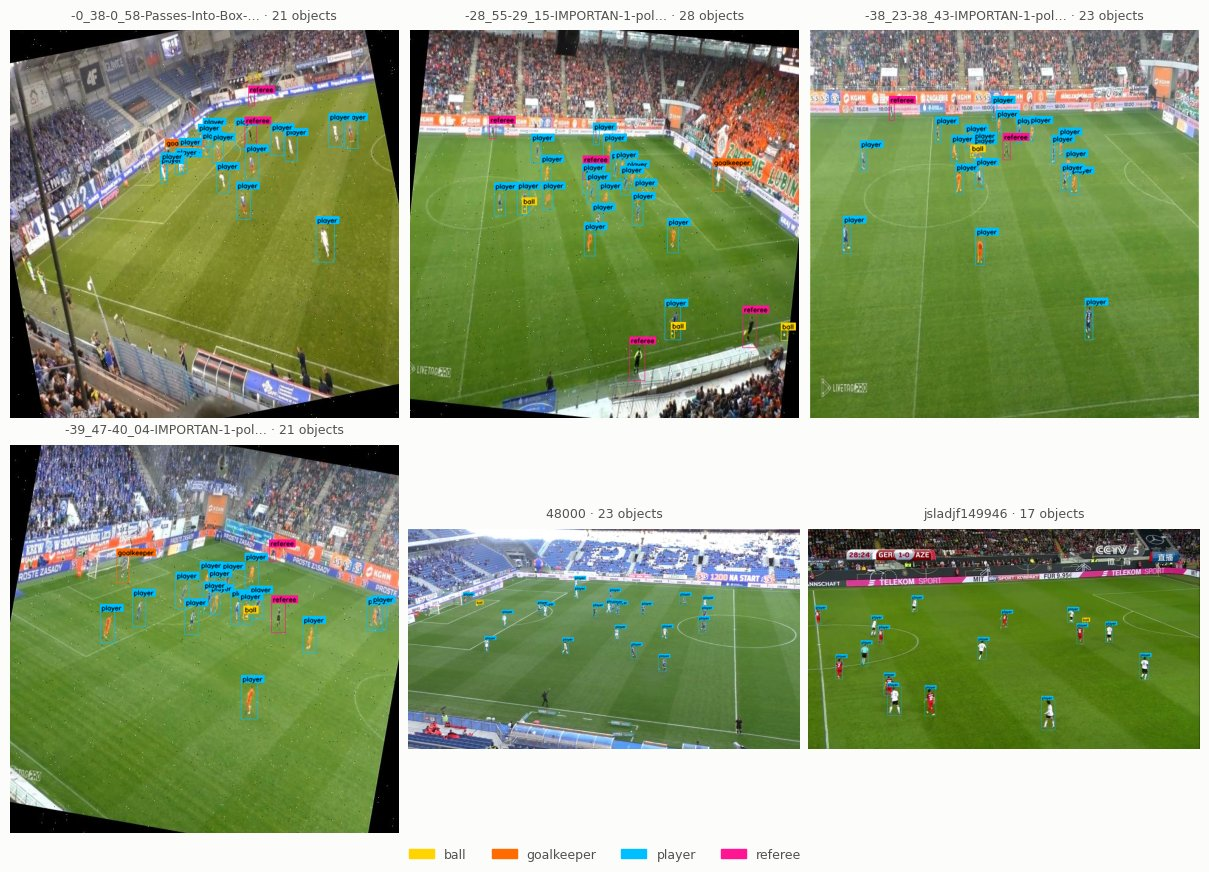

In [3]:
tv.viz.show_samples(detection, "train", n=6, seed=1)

Each split is a list of `Sample`s: the image path, its size and the
`Annotations` in pixel coordinates. `read` loads the image (BGR, as in OpenCV)
together with a copy of its labels.

In [4]:
sample = detection["train"][0]
image, annotations = detection.read("train", 0)
print("image:", image.shape, image.dtype, f"({sample.width}x{sample.height})")
print("objects:", len(annotations))
pd.DataFrame(annotations.boxes, columns=["x1", "y1", "x2", "y2"]).assign(
    class_name=[detection.class_names[i] for i in annotations.class_ids]
).head().round(1)

image: (640, 640, 3) uint8 (640x640)
objects: 18


,x1,y1,x2,y2,class_name
0,47.0,392.0,65.5,464.5,player
1,158.0,310.0,177.5,368.0,player
2,264.0,332.0,286.5,390.0,player
3,283.0,387.0,305.5,468.0,player
4,290.0,194.0,302.5,241.5,player


## Deriving datasets

`subset`, `resplit`, `merge` and `with_split` each return a new dataset. They
cover the usual chores: a small subset for quick experiments, a fresh
train/valid/test split, combining two sources, or replacing one split.

`merge` and `with_split` take images from elsewhere and keep every image they
are given, so the sources should not overlap. Here the second source is a
`Dataset` built from detection images that `small` left out.

In [5]:
small = detection.subset({"train": 200, "valid": 40}, seed=0)  # counts per split
tenth = detection.subset(0.1, seed=0)  # a fraction of every split
resplit = small.resplit(train=0.7, valid=0.2, test=0.1, seed=0)  # pool and split again

in_small = {s.image_path for s in small}
unused = {
    split: [s for s in detection[split] if s.image_path not in in_small]
    for split in ("train", "valid")
}
extra = tv.data.Dataset(
    detection.task, detection.class_names, {"train": unused["train"][:100]}
)
merged = small.merge(extra)  # same classes required
held_out = small.with_split(
    "test", unused["valid"][:30]
)  # a test split small has not seen

print(
    "distinct images in merged:", len({s.image_path for s in merged}), "of", len(merged)
)
pd.concat(
    {
        name: ds.summary()[["images", "objects"]]
        for name, ds in {
            "small": small,
            "tenth": tenth,
            "resplit": resplit,
            "merged": merged,
            "held_out": held_out,
        }.items()
    },
    names=["dataset"],
)

distinct images in merged: 340 of 340


images  objects
dataset  split                 
small    train     200     4226
         valid      40      789
tenth    train     126     2684
         valid      19      405
resplit  train     168     3472
         valid      48     1046
         test       24      497
merged   train     300     6485
         valid      40      789
held_out train     200     4226
         valid      40      789
         test       30      730

## Converting between YOLO and COCO

Ultralytics trains on YOLO folders and RF-DETR on COCO folders. `to_yolo` and
`to_coco` write either layout from any dataset. Images are symlinked by default
(`link="hardlink"` or `"copy"` also work) and labels are written fresh. The
trainers call these for you; here we call them directly and check that a
round trip YOLO → COCO → YOLO keeps every box and class.

In [6]:
coco_root = small.to_coco(OUT / "football_coco")
from_coco = tv.load_dataset(coco_root)
yolo_yaml = from_coco.to_yolo(OUT / "football_yolo_again")
from_yolo = tv.load_dataset(yolo_yaml)

print("COCO:", from_coco)
print("YOLO:", from_yolo)
print("files:", sorted(p.name for p in coco_root.iterdir()), "+", yolo_yaml.name)
print("images are symlinks:", next((coco_root / "train").glob("*.jpg")).is_symlink())

COCO: Dataset(name='football_coco', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=200, valid=40)
YOLO: Dataset(name='football_yolo_again', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=200, valid=40)
files: ['.tactifoot-export', 'train', 'valid'] + data.yaml
images are symlinks: True


The check compares labels image by image (keyed by file name), since a format
may store images in a different order. Writers clip boxes to the image, because
Ultralytics rejects coordinates outside it, so the source boxes are clipped the
same way before comparing.

In [7]:
def labels_by_image(dataset):
    # {(split, image stem): (class ids, boxes clipped to the image)}
    labels = {}
    for split in dataset.split_names:
        for sample in dataset[split]:
            a = sample.annotations
            size = [sample.width, sample.height] * 2
            labels[split, sample.image_path.stem] = (a.class_ids, a.boxes.clip(0, size))
    return labels


def same_labels(a, b, atol=1e-3):
    if a.keys() != b.keys():
        return False
    for key, (ids_a, boxes_a) in a.items():
        ids_b, boxes_b = b[key]
        # Same object order on both sides (YOLO stores 6 decimals, hence the rounding).
        order_a = np.lexsort((*np.round(boxes_a).T, ids_a))
        order_b = np.lexsort((*np.round(boxes_b).T, ids_b))
        if not (
            np.array_equal(ids_a[order_a], ids_b[order_b])
            and np.allclose(boxes_a[order_a], boxes_b[order_b], atol=atol)
        ):
            return False
    return True


original = labels_by_image(small)
outside = sum(
    int(
        (s.annotations.boxes != s.annotations.boxes.clip(0, [s.width, s.height] * 2))
        .any(axis=1)
        .sum()
    )
    for s in small
)
print("source boxes reaching outside their image:", outside)
print(
    "YOLO -> COCO identical:        ", same_labels(original, labels_by_image(from_coco))
)
print(
    "YOLO -> COCO -> YOLO identical:", same_labels(original, labels_by_image(from_yolo))
)

source boxes reaching outside their image: 8
YOLO -> COCO identical:         True
YOLO -> COCO -> YOLO identical: True


## Pose datasets and `flip_idx`

The pitch dataset is a pose task: each image has one `pitch` object with 32
landmark keypoints `(x, y, visibility)`. `flip_idx` says which landmark takes
the place of which when the image is mirrored (left corner ↔ right corner).
Augmentation needs it to flip keypoints correctly, see
[02_augmentation](02_augmentation.ipynb).

In [8]:
pitch_data = tv.load_dataset(DATA / "keypoints")
print(pitch_data)
print("flip_idx:", pitch_data.flip_idx)
pitch_data.summary()

Dataset(name='keypoints', task=pose, classes=['pitch'], keypoints=32, train=254, valid=34, test=28)
flip_idx: (24, 25, 26, 27, 28, 29, 22, 23, 21, 17, 18, 19, 20, 13, 14, 15, 16, 9, 10, 11, 12, 8, 6, 7, 0, 1, 2, 3, 4, 5, 31, 30)


,images,objects,pitch
split,,,
train,254,254,254
valid,34,34,34
test,28,28,28


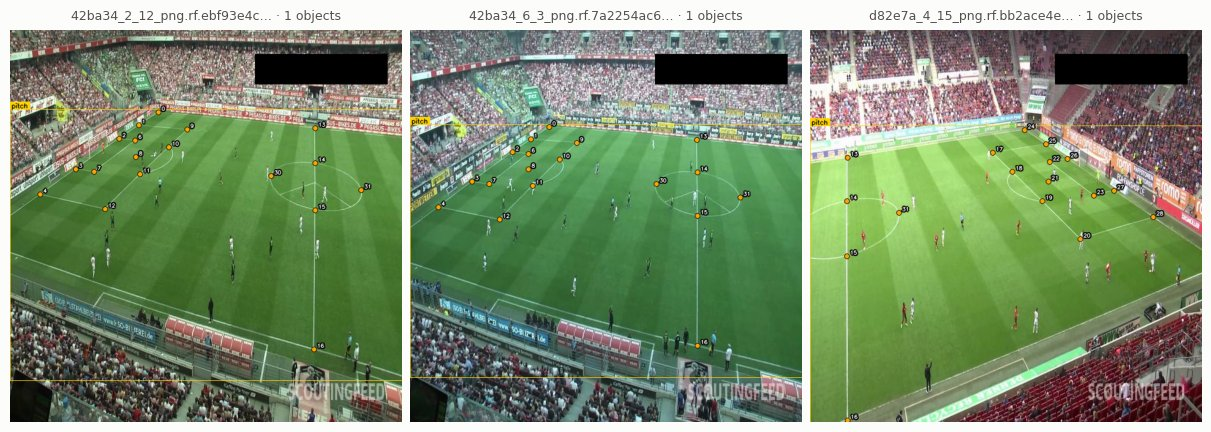

In [9]:
tv.viz.show_samples(pitch_data, "train", n=3)

Visibility follows YOLO and COCO: 0 not labelled, 1 occluded, 2 visible. A
broadcast frame shows only part of the pitch, so most landmarks of an image
are unlabelled.

In [10]:
keypoints = np.concatenate([s.annotations.keypoints for s in pitch_data["train"]])
visibility = pd.Series(keypoints[..., 2].ravel()).map(
    {
        tv.data.NOT_LABELLED: "not labelled",
        tv.data.OCCLUDED: "occluded",
        tv.data.VISIBLE: "visible",
    }
)
print("keypoints per object:", keypoints.shape[1])
visibility.value_counts(normalize=True).round(3).to_frame("share of keypoints")

keypoints per object: 32


,share of keypoints
not labelled,0.524
visible,0.475
occluded,0.000


COCO has no field for `flip_idx`; the writer stores it on the category so the
round trip keeps it. Labelled keypoints come back unchanged; unlabelled ones
are written as `0 0 0`, so only their visibility is compared.

In [11]:
pitch_subset = pitch_data.subset(20, seed=0)
pitch_coco = tv.load_dataset(pitch_subset.to_coco(OUT / "pitch_coco"))
print(pitch_coco)
print("flip_idx kept:", pitch_coco.flip_idx == pitch_data.flip_idx)


def keypoints_by_image(dataset):
    return {
        (split, s.image_path.stem): s.annotations.keypoints
        for split in dataset.split_names
        for s in dataset[split]
    }


before, after = keypoints_by_image(pitch_subset), keypoints_by_image(pitch_coco)
same = before.keys() == after.keys()
for key, kp in before.items():
    labelled = kp[..., 2] > tv.data.NOT_LABELLED
    same &= np.array_equal(kp[..., 2], after[key][..., 2])
    same &= np.allclose(kp[labelled], after[key][labelled], atol=1e-3)
print("keypoints kept:", bool(same))

Dataset(name='pitch_coco', task=pose, classes=['pitch'], keypoints=32, train=20, valid=20, test=20)
flip_idx kept: True
keypoints kept: True


## Match video

`VideoReader` gives the video's properties and reads frames in order
(`frames(start, end, stride)` yields `(index, frame)` pairs) or one at a time
by index. Frames are BGR arrays, like dataset images.

VideoReader('../data/videos/broadcast_60s.mp4', 1920x1080, 25.00 fps, 1499 frames)
1920x1080, 25 fps, 1499 frames, 60 s


frames read: [0, 250, 500, 750, 1000, 1250]


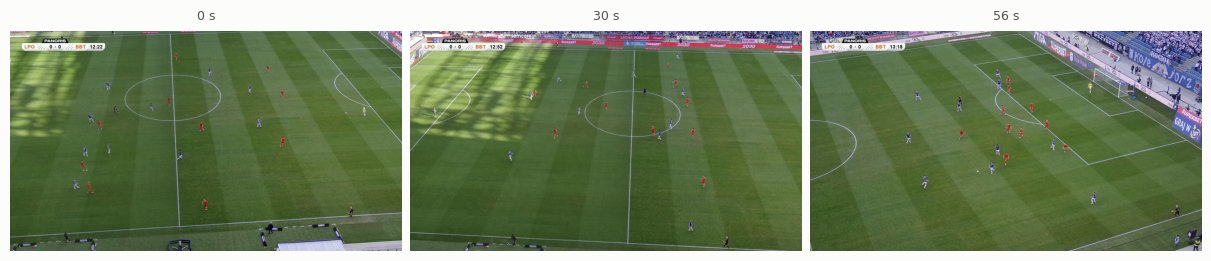

In [12]:
video = tv.VideoReader(VIDEO)
print(video)
print(
    f"{video.width}x{video.height}, {video.fps:.0f} fps, {video.frame_count} frames, {video.duration:.0f} s"
)

every_ten_seconds = list(video.frames(start=0, end=video.frame_count, stride=250))
print("frames read:", [index for index, _ in every_ten_seconds])
tv.show([video.read(i) for i in (0, 750, 1400)], titles=["0 s", "30 s", "56 s"])

`extract_frames` saves every `stride`-th frame of `start <= index < end` as an
image (the same frame range as `VideoReader.frames`), the usual first step when
annotating new footage.

In [13]:
paths = tv.data.extract_frames(VIDEO, OUT / "frames", end=1500, stride=375)
print([path.name for path in paths])

['broadcast_60s_000000.jpg', 'broadcast_60s_000375.jpg', 'broadcast_60s_000750.jpg', 'broadcast_60s_001125.jpg']


## StatsBomb 360 events

`load_statsbomb` reads a match's `*_events.json` and `*_360.json` (or a CSV
saved from the same table) into one row per player visible in an event's
freeze frame. Locations are in StatsBomb's 120 × 80 pitch units. This is the
reference that pipeline positions can be compared against, see
[04_inference](04_inference.ipynb).

In [14]:
statsbomb = tv.data.load_statsbomb(DATA / "statsbomb")
print(
    f"{len(statsbomb):,} objects in {statsbomb['event_uuid'].nunique():,} freeze frames"
)
statsbomb[
    [
        "period",
        "minute",
        "second",
        "type_name",
        "team_name",
        "pitch_location",
        "teammate",
        "type",
    ]
].head()

42,364 objects in 2,931 freeze frames


,period,minute,second,type_name,team_name,pitch_location,teammate,type
0,1,35,35,Pass,Zagłębie Lubin,"[68.63410078644921, 62.19655683191594]",False,player
1,1,35,35,Pass,Zagłębie Lubin,"[75.67729395595688, 32.24870399772143]",False,player
2,1,35,35,Pass,Zagłębie Lubin,"[76.82714361999138, 38.02748109694302]",False,player
3,1,35,35,Pass,Zagłębie Lubin,"[73.44072568446902, 71.68117427038213]",False,player
4,1,35,35,Pass,Zagłębie Lubin,"[84.96868639155238, 48.873848093157335]",True,player


`tv.viz.draw_pitch` takes any pitch size, so a freeze frame can be checked at a
glance: the actor's team in blue, opponents in pink.

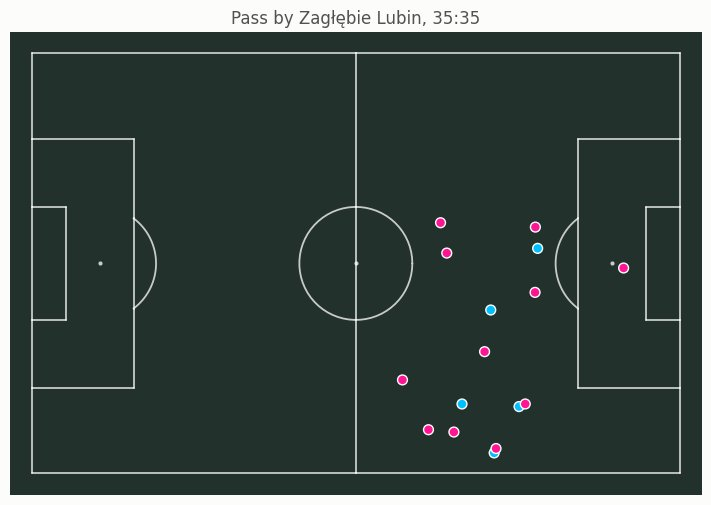

In [15]:
event = statsbomb[statsbomb["event_uuid"] == statsbomb["event_uuid"].iloc[0]]
first = event.iloc[0]
xy = np.array(event["pitch_location"].tolist())

fig = tv.viz.draw_pitch(pitch=tv.SoccerPitch(120, 80), size=7)
ax = fig.axes[0]
ax.scatter(
    xy[:, 0],
    xy[:, 1],
    s=50,
    zorder=3,
    edgecolor="white",
    c=np.where(event["teammate"], "#00BFFF", "#FF1493"),
)
ax.set_title(
    f"{first.type_name} by {first.team_name}, {first.minute}:{first.second:02d}"
)
fig